In [7]:
# Mount Drive (if not already mounted)
from google.colab import drive
drive.mount('/content/drive')

# Create Kaggle directory
!mkdir -p ~/.kaggle

# Copy kaggle.json from Google Drive
!cp "/content/drive/MyDrive/Project/DENTEX/kaggle.json" ~/.kaggle/

# Set proper permissions
!chmod 600 ~/.kaggle/kaggle.json

# Verify installation
!ls -la ~/.kaggle

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
total 16
drwxr-xr-x 2 root root 4096 Jun  4 00:49 .
drwx------ 1 root root 4096 Jun  4 00:49 ..
-rw------- 1 root root   73 Jun  4 02:00 kaggle.json


In [2]:
# Create a data directory
%mkdir -p dentex_data

# Download dataset via Kaggle API command
!kaggle datasets download smmansoor340/dentexchallengesample

# # Unzip the content and remove the original zip file to save space
!unzip -q /content/dentexchallengesample.zip -d dentex_dataset
!rm /content/dentexchallengesample.zip

print("Dataset downloaded and extracted successfully.")

Dataset URL: https://www.kaggle.com/datasets/smmansoor340/dentexchallengesample
License(s): ODbL-1.0
100% 734M/734M [00:44<00:00, 17.3MB/s]

Dataset downloaded and extracted successfully.


In [12]:
import json
import os

# 1. Print out the extracted contents
print("--- Extracted Directory Layout ---")
for root, dirs, files in os.walk('dentex_data'):
    level = root.replace('dentex_data', '').count(os.sep)
    indent = ' ' * 4 * (level)
    print(f"{indent}{os.path.basename(root)}/")
    subindent = ' ' * 4 * (level + 1)
    for f in files[:3]:  # Print up to 3 sample files per folder
        print(f"{subindent}{f}")

# 2. Look inside one of the json annotation sets (e.g., quadrant-enumeration-diagnosis)
# Change the filename below depending on the exact name printed in the layout above
json_paths = [os.path.join(r, f) for r, d, fs in os.walk('dentex_data') for f in fs if f.endswith('.json')]

if json_paths:
    print("\n--- Reading Metadata Key Structure ---")
    with open(json_paths[0], 'r') as file:
        sample_coco = json.load(file)
        print(f"File selected: {json_paths[0]}")
        print(f"Top Level Keys: {list(sample_coco.keys())}")
        print(f"Total Images Annotated: {len(sample_coco.get('images', []))}")
        print(f"Total Annotations Found: {len(sample_coco.get('annotations', []))}")
        if 'categories' in sample_coco:
            print(f"Sample Categories/Classes: {sample_coco['categories'][:5]}")
else:
    print("\n[!] No JSON annotation files discovered. Double check extraction layout.")

--- Extracted Directory Layout ---
dentex_data/
    validation_data/
        validation_data/
            quadrant_enumeration_disease/
                xrays/
                    val_47.png
                    val_3.png
                    val_16.png
                    .ipynb_checkpoints/
                        val_0-checkpoint.png
    training_data/
        training_data/
            unlabelled/
                xrays/
                    train_1009.png
                    train_970.png
                    train_497.png
            quadrant_enumeration/
                train_quadrant_enumeration.json
                xrays/
                    train_497.png
                    train_227.png
                    train_342.png
            quadrant-enumeration-disease/
                train_quadrant_enumeration_disease.json
                xrays/
                    train_497.png
                    train_227.png
                    train_342.png
            quadrant/
                trai

Found 3653 total x-ray images.


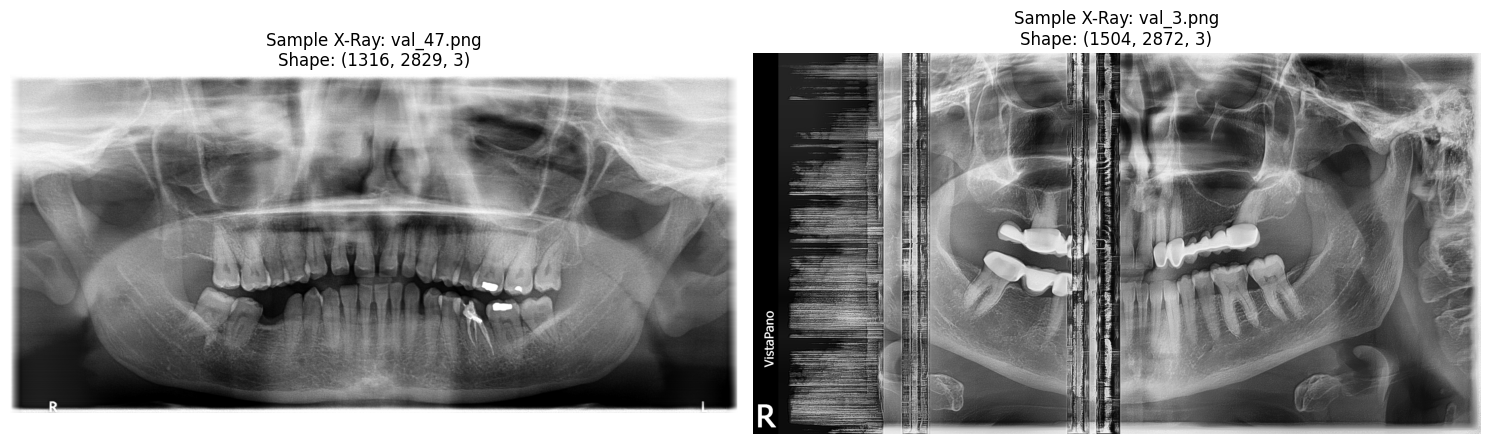

In [ ]:
import cv2
import matplotlib.pyplot as plt
import glob

# Find all paths matching typical image formats inside the target directory
image_extensions = ('/**/*.png', '/**/*.jpg', '/**/*.jpeg')
image_paths = []
for ext in image_extensions:
    image_paths.extend(glob.glob('dentex_data' + ext, recursive=True))

if image_paths:
    print(f"Found {len(image_paths)} total x-ray images.")

    # Plot the first 2 images
    fig, axes = plt.subplots(1, 2, figsize=(15, 7))
    for i, img_path in enumerate(image_paths[:2]):
        img = cv2.imread(img_path)
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        axes[i].imshow(img_rgb)
        axes[i].set_title(f"Sample X-Ray: {os.path.basename(img_path)}\nShape: {img.shape}")
        axes[i].axis('off')
    plt.tight_layout()
    plt.show()
else:
    print("[!] No images found. Check if paths inside 'dentex_data' are nested in subfolders.")

In [3]:
!git clone https://github.com/smmansoor1994/WILP.git

Cloning into 'WILP'...
remote: Enumerating objects: 82, done.
remote: Counting objects: 100% (82/82), done.
remote: Compressing objects: 100% (64/64), done.
remote: Total 82 (delta 11), reused 47 (delta 5), pack-reused 0 (from 0)
Receiving objects: 100% (82/82), 152.06 KiB | 1.88 MiB/s, done.
Resolving deltas: 100% (11/11), done.


In [4]:
%cd WILP

/content/WILP


In [5]:
!pip install -r requirements.txt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 60.8 MB/s eta 0:00:00


In [6]:
!python main.py --mode full --device cuda --dentex-root /content/dentex_dataset/DENTEXsample

2026-06-04 02:15:19 [INFO] yolortho.main — YOLOrtho — Mode: full | Device: cuda
2026-06-04 02:15:19 [INFO] yolortho.main — ======================================================================
2026-06-04 02:15:19 [INFO] yolortho.main —   YOLOrtho FULL PIPELINE
2026-06-04 02:15:19 [INFO] yolortho.main —   Paper: https://arxiv.org/abs/2308.05967
2026-06-04 02:15:19 [INFO] yolortho.main —   Dataset: DENTEX (on disk at --dentex-root)
2026-06-04 02:15:19 [INFO] yolortho.main — ======================================================================
2026-06-04 02:15:19 [INFO] yolortho.main — 
2026-06-04 02:15:19 [INFO] yolortho.main — ============================================================
2026-06-04 02:15:19 [INFO] yolortho.main —   STAGE 1 — Preprocess Data to YOLO Format
2026-06-04 02:15:19 [INFO] yolortho.main — ============================================================
2026-06-04 02:15:19 [INFO] src.data.preprocess — Processing Part 1 (quadrant) from '/content/dentex_dataset/DENTE